/var/folders/nj/jy9kb34503nb3927j498k11m0000gn/T/ipykernel_24490/416037807.py:63: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  m1 = pairs.groupby("date", group_keys=False).apply(lambda g: select_target_expiry(g, 30))
/var/folders/nj/jy9kb34503nb3927j498k11m0000gn/T/ipykernel_24490/416037807.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  m6 = pairs.groupby("date", group_keys=False).apply(lambda g: select_target

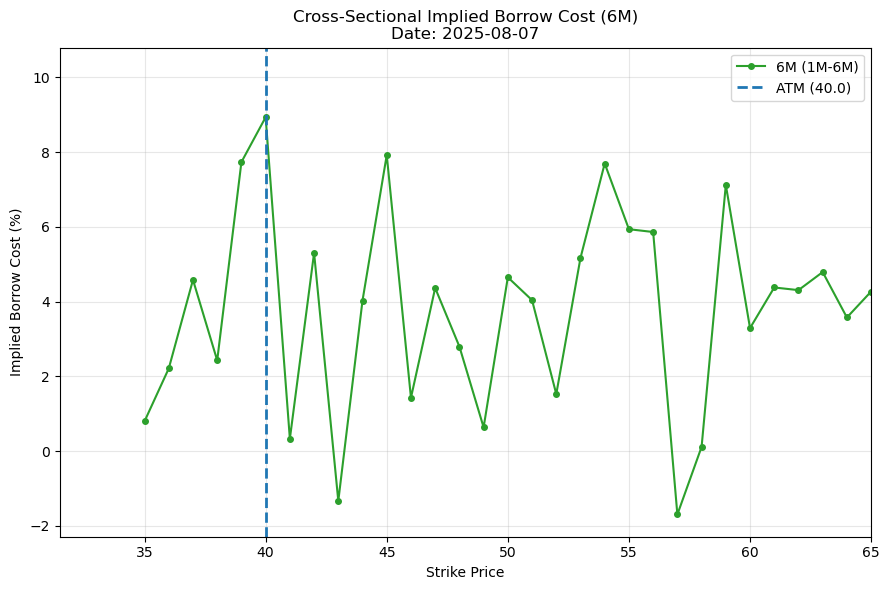

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def prepare_data(df):
    """Clean columns and standardize formats immediately."""
    df.columns = [c.lower().strip() for c in df.columns]
    df["date"] = pd.to_datetime(df["date"])
    df["exdate"] = pd.to_datetime(df["exdate"])

    # Handle Strike Price (OptionMetrics 1000x scaling)
    if df["strike_price"].max() > 5000:
        df["strike"] = df["strike_price"] / 1000.0
    else:
        df["strike"] = df["strike_price"]

    df["mid"] = (df["best_bid"] + df["best_offer"]) / 2.0

    # Basic filters
    df = df[(df["best_bid"] > 0) & (df["best_offer"] > df["best_bid"])].copy()
    return df

def select_target_expiry(group, target_days, tolerance=20):
    """Find the single expiry closest to the target maturity."""
    unique_expiries = group[["exdate", "days_to_expiry"]].drop_duplicates().copy()
    unique_expiries["diff"] = (unique_expiries["days_to_expiry"] - target_days).abs()

    if unique_expiries.empty:
        return pd.DataFrame()
        
    best_row = unique_expiries.sort_values("diff").iloc[0]
    if best_row["diff"] <= tolerance:
        return group[group["exdate"] == best_row["exdate"]]
    return pd.DataFrame()

def run_borrow_cost_analysis(options_df, r=0.045):
    # 1. Prepare data
    df = prepare_data(options_df)

    calls = df[df["cp_flag"] == "C"].copy()
    puts  = df[df["cp_flag"] == "P"].copy()

    calls = calls.rename(columns={"mid": "c_mid"})
    puts  = puts.rename(columns={"mid": "p_mid"})

    # Keep only needed columns before merge
    calls = calls[["date", "exdate", "strike", "c_mid"]]
    puts  = puts[["date", "exdate", "strike", "p_mid"]]

    # 2. Merge call/put pairs
    pairs = pd.merge(calls, puts, on=["date", "exdate", "strike"], how="inner")

    # 3. Maturity
    pairs["days_to_expiry"] = (pairs["exdate"] - pairs["date"]).dt.days
    pairs = pairs[pairs["days_to_expiry"] > 0].copy()
    pairs["T"] = pairs["days_to_expiry"] / 365.0

    # 4. A = C - P + K exp(-rT)
    pairs["A"] = pairs["c_mid"] - pairs["p_mid"] + pairs["strike"] * np.exp(-r * pairs["T"])
    pairs = pairs[pairs["A"] > 0].copy()

    # 5. Select 1-month and 6-month expiries
    m1 = pairs.groupby("date", group_keys=False).apply(lambda g: select_target_expiry(g, 30))
    m6 = pairs.groupby("date", group_keys=False).apply(lambda g: select_target_expiry(g, 182))

    if m1.empty or m6.empty:
        raise ValueError("Could not find enough 1-month or 6-month expiries within tolerance.")

    # 6. Cross-sectional merge
    cross = pd.merge(
        m1[["date", "strike", "A", "T", "days_to_expiry"]],
        m6[["date", "strike", "A", "T", "days_to_expiry"]],
        on=["date", "strike"],
        suffixes=("_1", "_2")
    )

    # 7. Implied borrow cost calculation
    cross = cross[cross["T_2"] > cross["T_1"]].copy()
    cross["implied_bc"] = (np.log(cross["A_1"]) - np.log(cross["A_2"])) / (cross["T_2"] - cross["T_1"])
    cross["bc_pct"] = cross["implied_bc"] * 100

    # --- NEW: OUTLIER FILTERING STEP ---
    # We remove strikes where bc_pct is more than 3 standard deviations from the daily mean
    def filter_daily_outliers(group):
        if len(group) < 3: return group # Can't calculate z-score for very small samples
        z_scores = (group["bc_pct"] - group["bc_pct"].mean()).abs() / group["bc_pct"].std()
        return group[z_scores < 3] # Keep only values within 3 standard deviations

    cross = cross.groupby("date", group_keys=False).apply(filter_daily_outliers).copy()
    
    # Final sanity range check
    cross = cross[cross["bc_pct"].between(-30, 30)].copy()

    # 8. Term structure summary
    term_structure = (
        cross.groupby("date")
        .agg(
            bc_pct=("bc_pct", "median"),
            days_to_expiry_1=("days_to_expiry_1", "first"),
            days_to_expiry_2=("days_to_expiry_2", "first"),
            n_strikes=("strike", "count")
        )
        .sort_index()
    )

    return term_structure, cross

def plot_results(term, cross, df, r=0.045):
    latest_date = cross["date"].max()
    latest_data = cross[cross["date"] == latest_date].sort_values("strike")

    # Calculate ATM using forward estimation method
    df_latest = df[df["date"] == latest_date].copy()
    atm_strike = None
    if len(df_latest) > 0:
        # Recalculate A values for this date
        calls = df_latest[df_latest["cp_flag"] == "C"][["exdate", "strike", "mid"]].rename(columns={"mid": "c_mid"})
        puts = df_latest[df_latest["cp_flag"] == "P"][["exdate", "strike", "mid"]].rename(columns={"mid": "p_mid"})
        pairs_date = pd.merge(calls, puts, on=["exdate", "strike"])
        
        pairs_date["days_to_expiry"] = (pd.to_datetime(pairs_date["exdate"]) - pd.to_datetime(latest_date)).dt.days
        pairs_date["T"] = pairs_date["days_to_expiry"] / 365.0
        pairs_date["A"] = pairs_date["c_mid"] - pairs_date["p_mid"] + pairs_date["strike"] * np.exp(-r * pairs_date["T"])
        pairs_date = pairs_date[pairs_date["A"] > 0].copy()
        
        if len(pairs_date) > 0:
            # Use middle strikes (30th-70th percentile) for more robust forward estimation
            mid_strikes = pairs_date[
                pairs_date["strike"].between(
                    pairs_date["strike"].quantile(0.3),
                    pairs_date["strike"].quantile(0.7)
                )
            ]
            
            if len(mid_strikes) > 0:
                F_est = mid_strikes["A"].median()
                
                # Then find closest strike to that forward
                pairs_date["fwd_diff"] = (pairs_date["strike"] - F_est).abs()
                atm_strike = pairs_date.loc[pairs_date["fwd_diff"].idxmin(), "strike"]

    fig1, ax1 = plt.subplots(figsize=(9, 6))
    ax1.plot(latest_data["strike"], latest_data["bc_pct"], marker="o", markersize=4, color='tab:green', label="6M (1M-6M)")

    # Add ATM vertical line if available
    if atm_strike is not None:
        ax1.axvline(x=atm_strike, linestyle='--', linewidth=2, label=f'ATM ({atm_strike:.1f})')

    ax1.set_title(f"Cross-Sectional Implied Borrow Cost (6M)\nDate: {latest_date.date()}")
    ax1.set_xlabel("Strike Price")
    ax1.set_ylabel("Implied Borrow Cost (%)")
    ax1.set_xlim(right=65)
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    fig1.tight_layout()
    fig1.savefig("cross_section_6M.png", dpi=300, bbox_inches="tight")
    plt.show()

# execution 
start_date = pd.Timestamp("2025-07-28")
df = pd.read_csv("b10xheebr3v3h1vn.csv", low_memory=False)
df["date"] = pd.to_datetime(df["date"])
df = df[df["date"] >= start_date].copy()
term, cross = run_borrow_cost_analysis(df)
plot_results(term, cross, df)